In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

# Datensatz laden
california = fetch_california_housing()

# Beschreibung des Datensatzes ausgeben
print(california.DESCR)

# Attribute anzeigen
print("\nFeature names:", california.feature_names)
print("Target name:", california.target_names)
print("Data shape:", california.data.shape)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib:
https://lib.stat.cmu.edu/datasets/houses.zip

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block g

In [4]:
# DataFrame aus den Daten erstellen
df_california = pd.DataFrame(
    california.data, 
    columns=california.feature_names
)

# Zielvariable hinzufügen
df_california['MedHouseVal'] = california.target

# Erste fünf Zeilen anzeigen
print("Erste 5 Zeilen des DataFrames:")
print(df_california.head())

# Informationen über den DataFrame anzeigen
print("\nInformationen zum DataFrame:")
print(df_california.info())

Erste 5 Zeilen des DataFrames:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Informationen zum DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   Av

In [5]:
# Summenstatistik des Datensatzes
print("Summenstatistik des Datensatzes:")
print(df_california.describe())

# Mittelwert der Spalte HouseAge
house_age_mean = df_california['HouseAge'].mean()
print(f"\nMittelwert der Spalte HouseAge: {house_age_mean:.6f}")

Summenstatistik des Datensatzes:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  

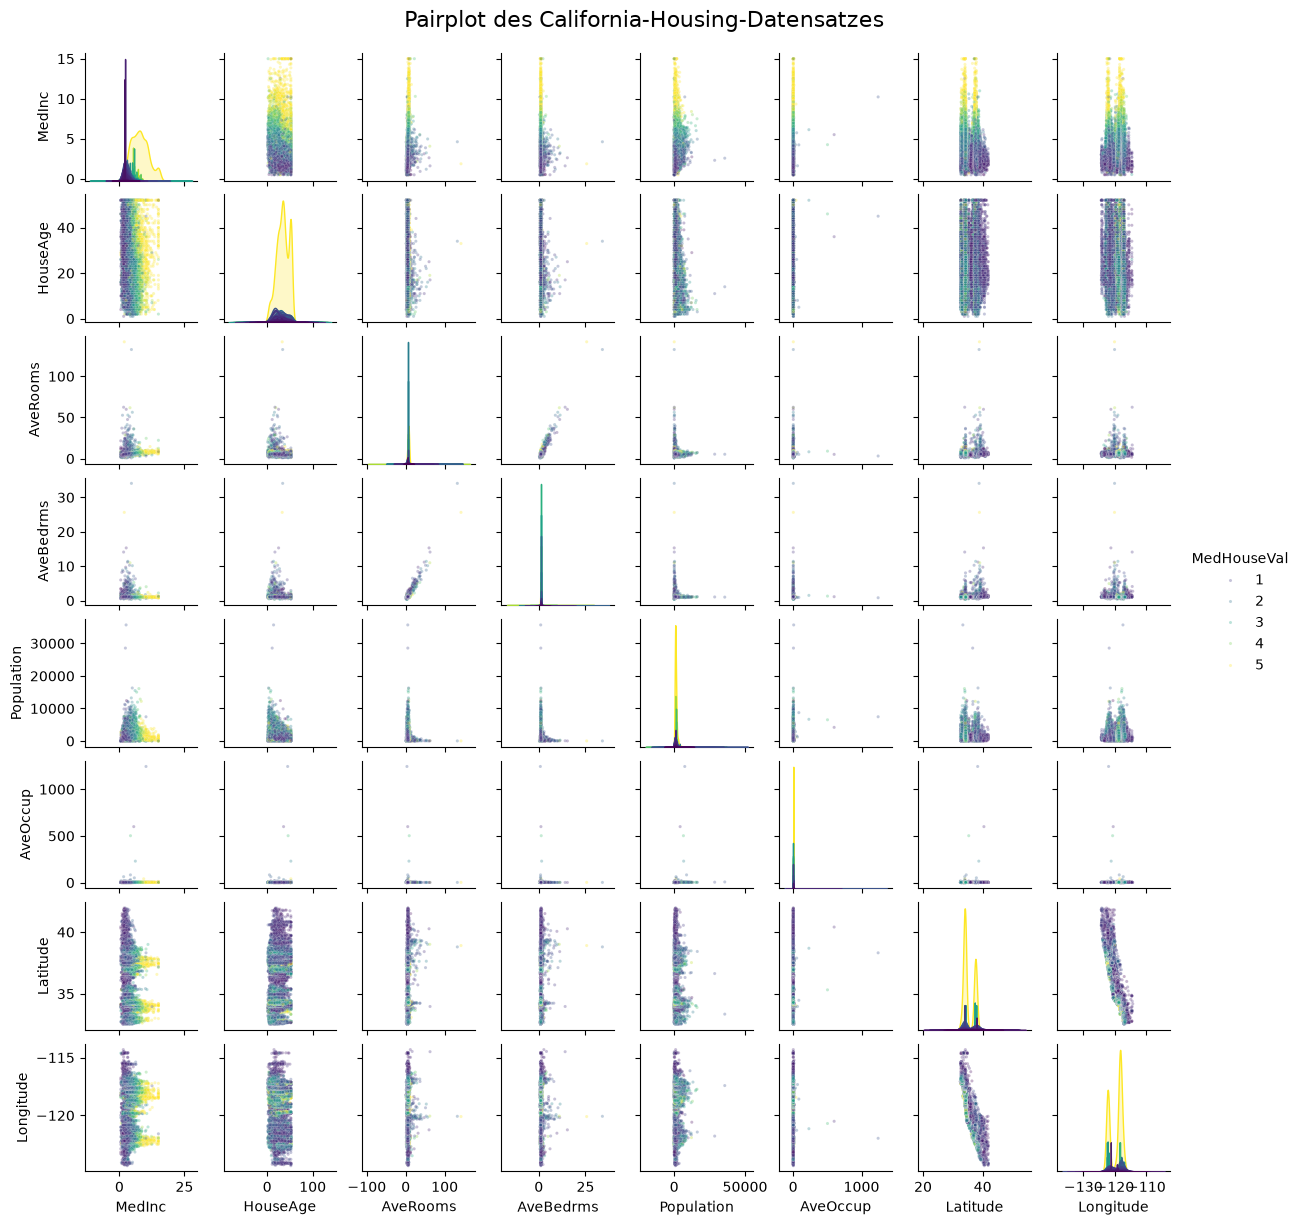

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pairplot erstellen
sns.pairplot(
    df_california,
    hue='MedHouseVal',
    palette='viridis',
    height=1.5,
    plot_kws={'alpha': 0.3, 's': 5}
)

# Titel setzen
plt.suptitle('Pairplot des California-Housing-Datensatzes', y=1.02, fontsize=16)

# Plot anzeigen
plt.show()

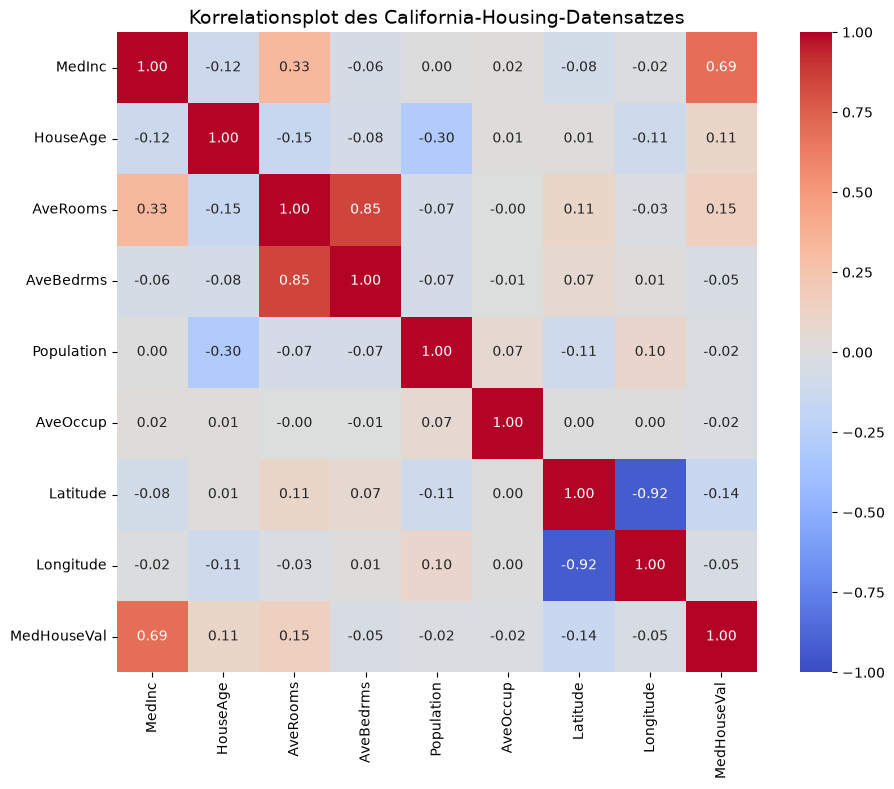


Korrelationen mit der Zielvariable MedHouseVal:
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

Die größte Korrelation mit MedHouseVal zeigt 'MedInc' mit einem Wert von 0.6881


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Korrelationsmatrix berechnen
corr_matrix = df_california.corr()

# Korrelationsplot erstellen
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,           # Werte in den Zellen anzeigen
    cmap='coolwarm',      # Farbpalette: blau-weiß-rot
    vmin=-1, vmax=1,      # Wertebereich -1 bis 1
    square=True,          # Quadratische Zellen
    fmt='.2f'             # 2 Nachkommastellen
)

plt.title('Korrelationsplot des California-Housing-Datensatzes', fontsize=14)
plt.tight_layout()
plt.show()

# Korrelationen mit der Zielvariable extrahieren
corr_with_target = corr_matrix['MedHouseVal'].sort_values(ascending=False)

print("\nKorrelationen mit der Zielvariable MedHouseVal:")
print(corr_with_target)

# Variable mit der größten Korrelation
highest_corr = corr_with_target.index[1]  # Index 0 = MedHouseVal (1.0)
highest_corr_value = corr_with_target.iloc[1]

print(f"\nDie größte Korrelation mit MedHouseVal zeigt '{highest_corr}' "
      f"mit einem Wert von {highest_corr_value:.4f}")

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Unabhängige Variablen (ohne Latitude und Longitude)
X = df_california.drop(['MedHouseVal', 'Latitude', 'Longitude'], axis=1)

# Zielvariable
y = df_california['MedHouseVal']

# Aufteilung in Trainings- und Testdaten (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Lineares Regressionsmodell erstellen und trainieren
model = LinearRegression()
model.fit(X_train, y_train)

# Vorhersage auf Testdaten
y_pred = model.predict(X_test)

# Metriken berechnen
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R2 Score: {r2:.4f}")

Mean Squared Error (MSE): 0.6422
R2 Score: 0.5099


max_depth= 1  R2 Score: 0.2795
max_depth= 2  R2 Score: 0.4244
max_depth= 3  R2 Score: 0.5098
max_depth= 4  R2 Score: 0.5542
max_depth= 5  R2 Score: 0.5938
max_depth= 6  R2 Score: 0.6135
max_depth= 7  R2 Score: 0.6293
max_depth= 8  R2 Score: 0.6326
max_depth= 9  R2 Score: 0.6078
max_depth=10  R2 Score: 0.5911
max_depth=11  R2 Score: 0.5717
max_depth=12  R2 Score: 0.5546
max_depth=13  R2 Score: 0.5267
max_depth=14  R2 Score: 0.4959
max_depth=15  R2 Score: 0.4664
max_depth=16  R2 Score: 0.4459
max_depth=17  R2 Score: 0.4363
max_depth=18  R2 Score: 0.4183
max_depth=19  R2 Score: 0.4176
max_depth=20  R2 Score: 0.4097

Die lineare Regression hat einen R2 Score von 0.5099
Der Entscheidungsbaum ist ab einer Tiefe von 4 besser als die lineare Regression.


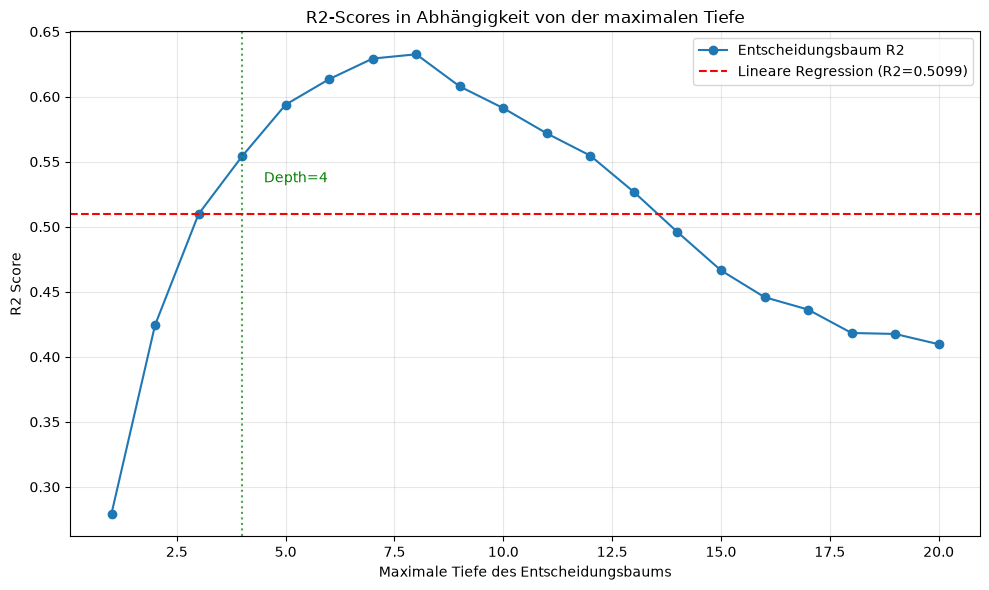

In [12]:
from sklearn.tree import DecisionTreeRegressor

# Unabhängige Variablen (ohne Latitude und Longitude)
X = df_california.drop(['MedHouseVal', 'Latitude', 'Longitude'], axis=1)
y = df_california['MedHouseVal']

# Train-Test-Split (gleicher Split wie in 2f)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# R2-Score der linearen Regression (aus 2f)
r2_linear = 0.5099

# Verschiedene Tiefen testen
depths = range(1, 21)
r2_scores = []
better_than_linear = None

for depth in depths:
    # Entscheidungsbaum mit aktueller Tiefe
    dt = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )
    dt.fit(X_train, y_train)
    y_pred = dt.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    r2_scores.append(r2)
    
    # Prüfen, ob besser als lineare Regression
    if r2 > r2_linear and better_than_linear is None:
        better_than_linear = depth
    
    print(f"max_depth={depth:2d}  R2 Score: {r2:.4f}")

print(f"\nDie lineare Regression hat einen R2 Score von {r2_linear:.4f}")
print(f"Der Entscheidungsbaum ist ab einer Tiefe von {better_than_linear} besser als die lineare Regression.")

# Plot der R2-Scores
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(depths, r2_scores, 'o-', label='Entscheidungsbaum R2')
plt.axhline(y=r2_linear, color='r', linestyle='--', label=f'Lineare Regression (R2={r2_linear:.4f})')
plt.xlabel('Maximale Tiefe des Entscheidungsbaums')
plt.ylabel('R2 Score')
plt.title('R2-Scores in Abhängigkeit von der maximalen Tiefe')
plt.legend()
plt.grid(True, alpha=0.3)

# Markiere den Punkt, ab dem der Baum besser ist
if better_than_linear:
    plt.axvline(x=better_than_linear, color='g', linestyle=':', alpha=0.7)
    plt.text(better_than_linear + 0.5, r2_scores[better_than_linear-1] - 0.02, 
             f'Depth={better_than_linear}', fontsize=10, color='green')

plt.tight_layout()
plt.show()

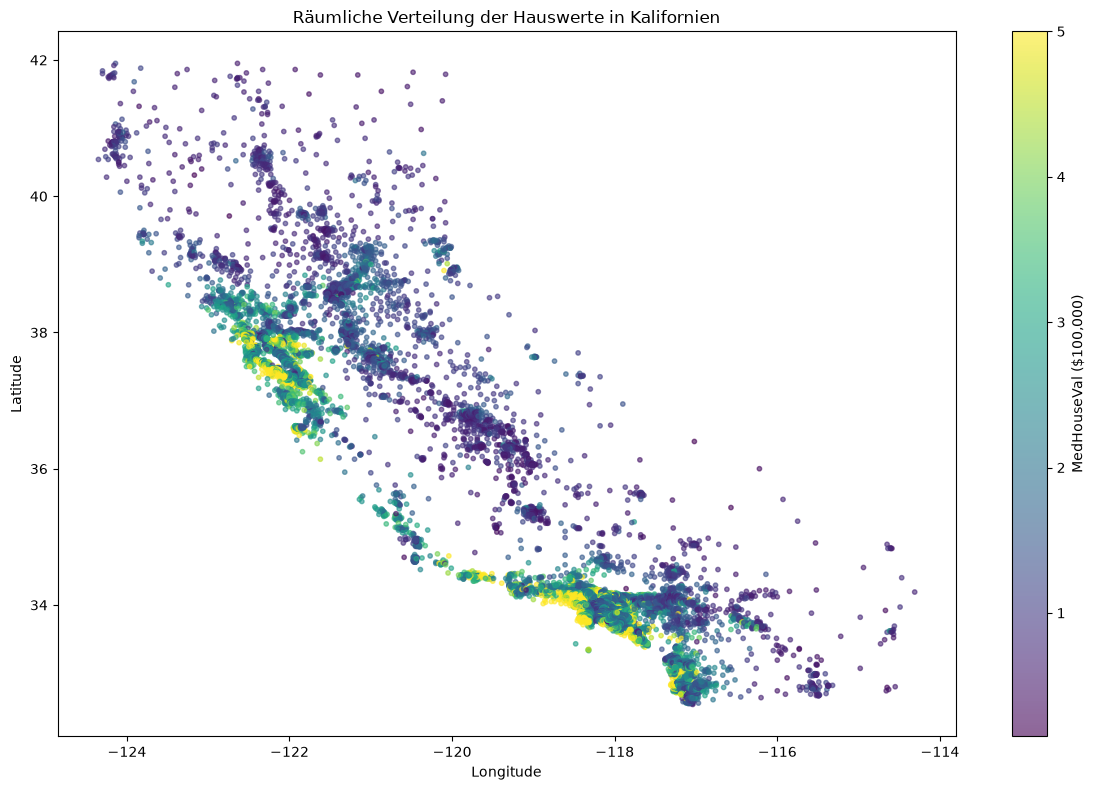

In [13]:
# Scatter-Plot der Hauswerte nach geografischer Lage
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    df_california['Longitude'],
    df_california['Latitude'],
    c=df_california['MedHouseVal'],
    cmap='viridis',
    s=10,
    alpha=0.6
)
plt.colorbar(scatter, label='MedHouseVal ($100,000)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Räumliche Verteilung der Hauswerte in Kalifornien')
plt.tight_layout()
plt.show()